In [3]:
import pandas as pd
import glob
import os

files = glob.glob("subreddits24/*_edges_2014_2025.csv")

print(f"Found {len(files)} files.")

df_list = []

for f in files:
    if os.path.getsize(f) > 0:  # Skip empty files
        try:
            df = pd.read_csv(f)
            if not df.empty:
                df_list.append(df)
            else:
                print(f"Skipping empty dataframe: {f}")
        except Exception as e:
            print(f"Error reading {f}: {e}")
    else:
        print(f"Skipping empty file: {f}")

global_df = pd.concat(df_list, ignore_index=True)

global_df = global_df.drop_duplicates()

# Clean subreddit names
global_df['SOURCE'] = global_df['SOURCE'].astype(str).str.lower().str.strip()
global_df['TARGET'] = global_df['TARGET'].astype(str).str.lower().str.strip()

# Ensure numeric columns correct
global_df['SENTIMENT'] = pd.to_numeric(global_df['SENTIMENT'], errors='coerce')
global_df['TIMESTAMP'] = pd.to_numeric(global_df['TIMESTAMP'], errors='coerce')

# Drop bad rows
global_df = global_df.dropna(subset=['SOURCE','TARGET','SENTIMENT','TIMESTAMP'])

# Convert to final types
global_df['SENTIMENT'] = global_df['SENTIMENT'].astype(int)
global_df['TIMESTAMP'] = global_df['TIMESTAMP'].astype(int)

global_df.to_parquet("reddit_signed_edges_2014_2025.parquet", index=False)

print("Merge complete.")
print(global_df.shape)

Found 231 files.
Error reading subreddits24/reddit.com_edges_2014_2025.csv: No columns to parse from file
Merge complete.
(10179780, 4)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter

# Reload from parquet
global_df = pd.read_parquet("reddit_signed_edges_2014_2025.parquet")
global_df['datetime'] = pd.to_datetime(global_df['TIMESTAMP'], unit='s')
global_df['year_month'] = global_df['datetime'].dt.to_period('M')
global_df['year'] = global_df['datetime'].dt.year

print(f"Total edges: {len(global_df):,}")
print(f"Date range: {global_df['datetime'].min()} → {global_df['datetime'].max()}")
print(f"Unique sources: {global_df['SOURCE'].nunique():,}")
print(f"Unique targets: {global_df['TARGET'].nunique():,}")
print(f"Sentiment counts:\n{global_df['SENTIMENT'].value_counts()}")

Total edges: 10,179,780
Date range: 2014-01-01 00:01:35 → 2024-12-31 23:59:18
Unique sources: 230
Unique targets: 423,083
Sentiment counts:
SENTIMENT
 1    7916966
-1    2262814
Name: count, dtype: int64


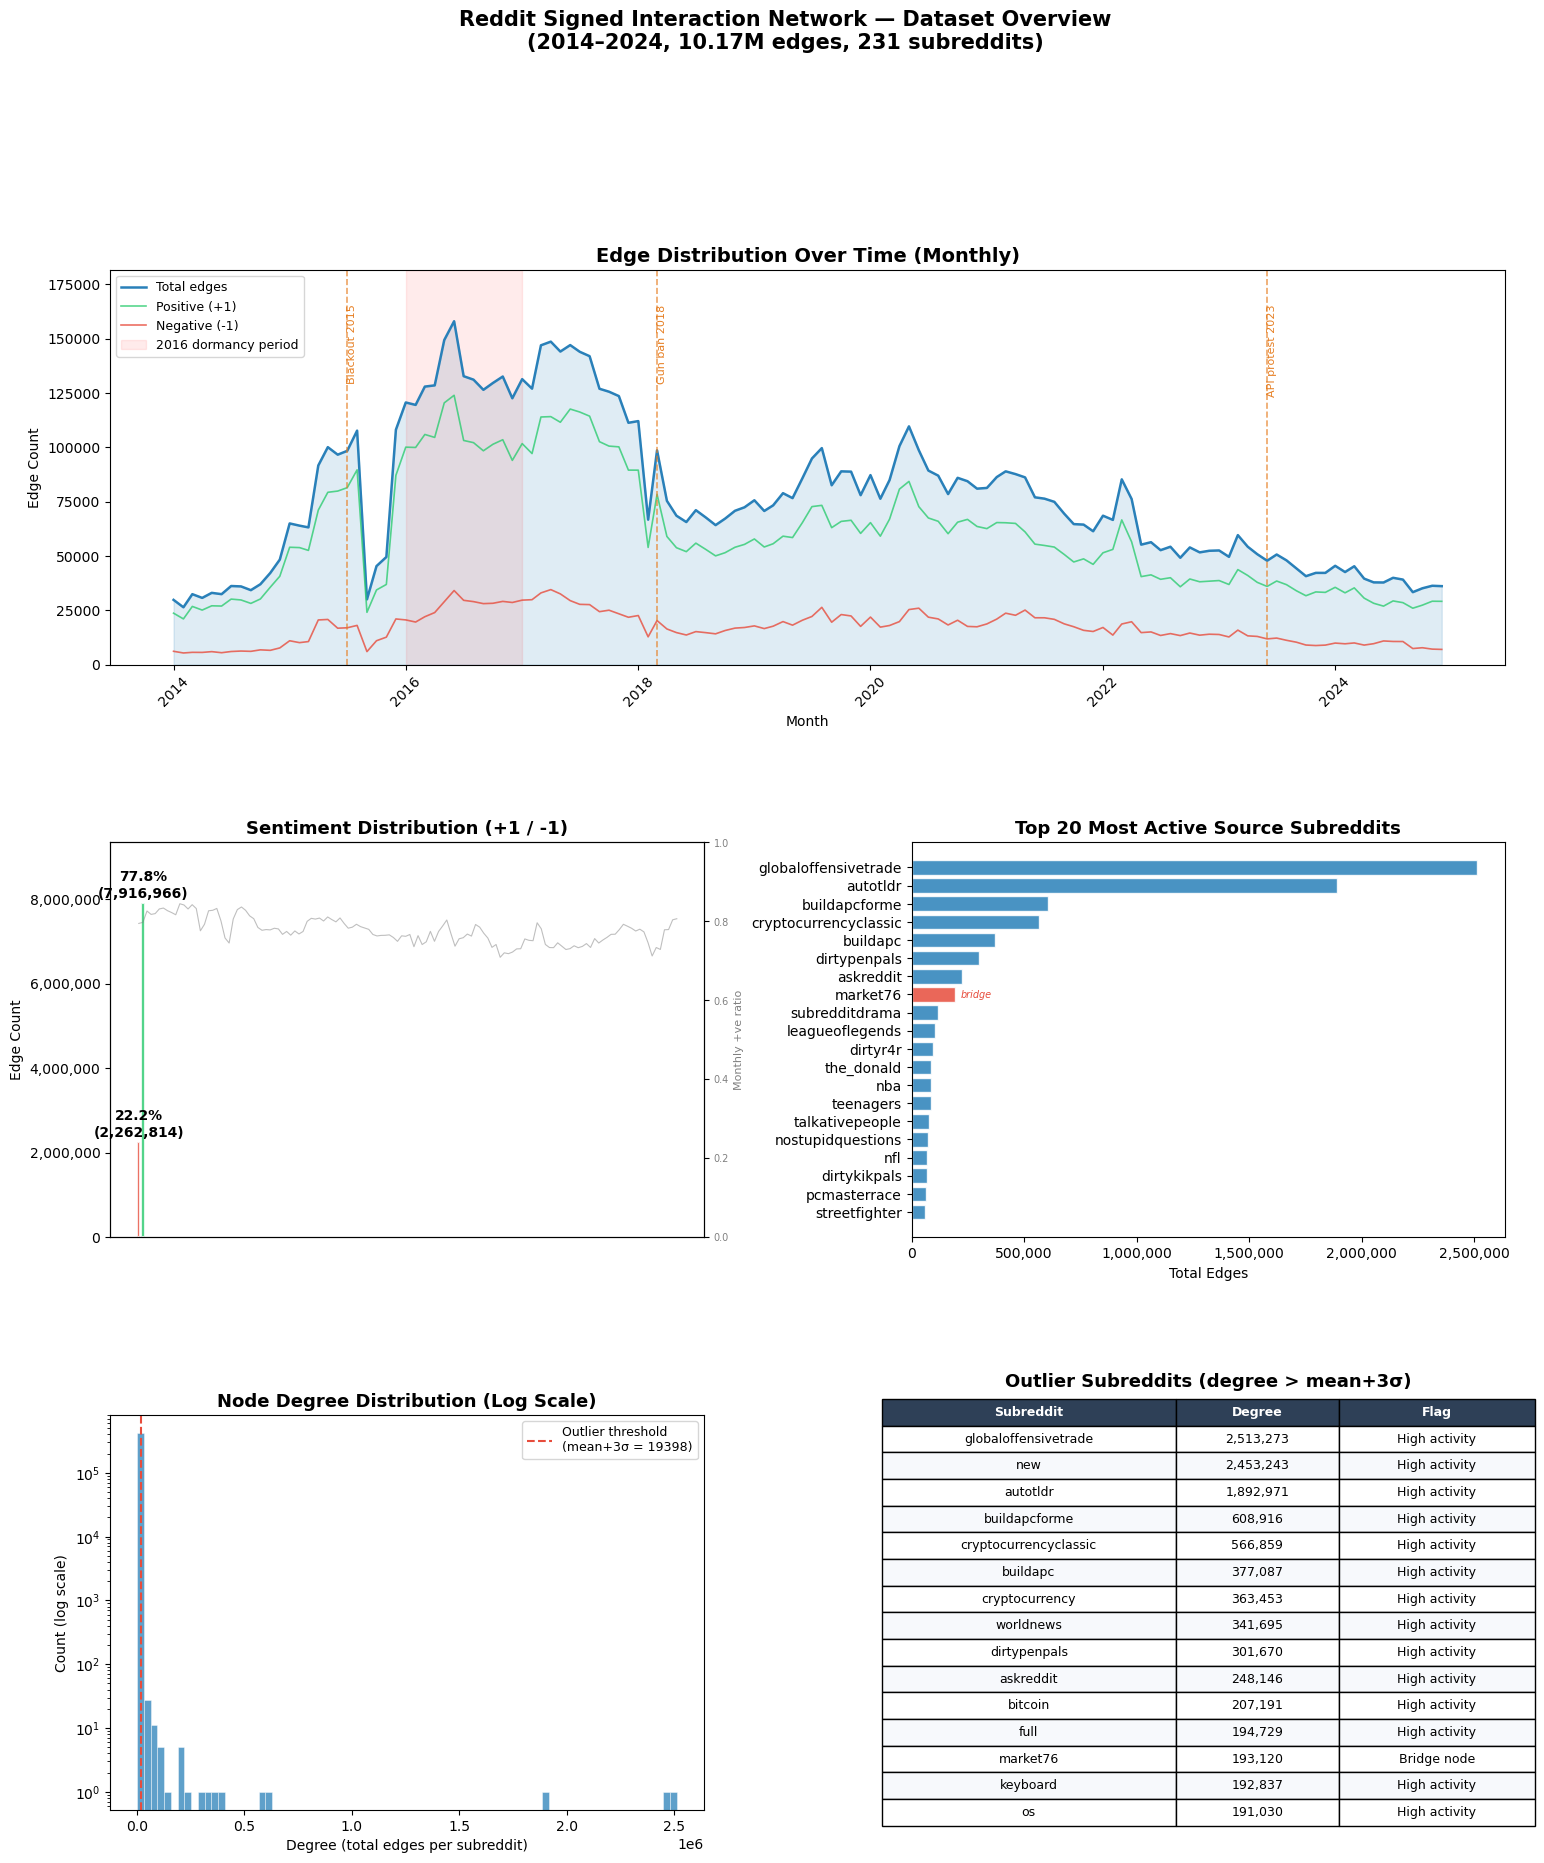

Saved: dataset_overview.png


In [3]:
fig = plt.figure(figsize=(18, 20))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── Colour palette ─────────────────────────────────────────────
POS_COL  = '#2ecc71'
NEG_COL  = '#e74c3c'
MAIN_COL = '#2980b9'
WARN_COL = '#e67e22'

# ════════════════════════════════════════════════════════════════
# PLOT 1 (top-left, full width): Edge distribution over time
# ════════════════════════════════════════════════════════════════
ax1 = fig.add_subplot(gs[0, :])

monthly_counts = global_df.groupby('year_month').size().reset_index(name='count')
monthly_counts['year_month_dt'] = monthly_counts['year_month'].dt.to_timestamp()

pos_monthly = global_df[global_df['SENTIMENT'] == 1].groupby('year_month').size().reset_index(name='pos')
neg_monthly = global_df[global_df['SENTIMENT'] ==-1].groupby('year_month').size().reset_index(name='neg')
pos_monthly['year_month_dt'] = pos_monthly['year_month'].dt.to_timestamp()
neg_monthly['year_month_dt'] = neg_monthly['year_month'].dt.to_timestamp()

ax1.fill_between(monthly_counts['year_month_dt'],
                 monthly_counts['count'], alpha=0.15, color=MAIN_COL)
ax1.plot(monthly_counts['year_month_dt'],
         monthly_counts['count'], color=MAIN_COL, linewidth=1.8, label='Total edges')
ax1.plot(pos_monthly['year_month_dt'],
         pos_monthly['pos'], color=POS_COL, linewidth=1.2, alpha=0.8, label='Positive (+1)')
ax1.plot(neg_monthly['year_month_dt'],
         neg_monthly['neg'], color=NEG_COL, linewidth=1.2, alpha=0.8, label='Negative (-1)')

# Mark the 2016 gap
ax1.axvspan(pd.Timestamp('2016-01-01'), pd.Timestamp('2016-12-31'),
            alpha=0.08, color='red', label='2016 dormancy period')

ax1.set_ylim(0, monthly_counts['count'].max() * 1.15)

# Mark validated conflict events
for event_date, label in [('2015-07-01', 'Blackout 2015'),
                           ('2018-03-01', 'Gun ban 2018'),
                           ('2023-06-01', 'API protest 2023')]:
    ax1.axvline(pd.Timestamp(event_date), color=WARN_COL,
                linestyle='--', linewidth=1.2, alpha=0.7)
    ax1.text(pd.Timestamp(event_date),
             monthly_counts['count'].max() * 1.05, 
             label, rotation=90, fontsize=8, color=WARN_COL, va='top')

ax1.set_title('Edge Distribution Over Time (Monthly)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Month')
ax1.set_ylabel('Edge Count')
ax1.legend(fontsize=9, loc='upper left')
ax1.xaxis.set_tick_params(rotation=45)

# ════════════════════════════════════════════════════════════════
# PLOT 2 (middle-left): Sentiment distribution
# ════════════════════════════════════════════════════════════════
ax2 = fig.add_subplot(gs[1, 0])

sentiment_counts = global_df['SENTIMENT'].value_counts().sort_index()
total = len(global_df)
labels = ['Negative (-1)', 'Positive (+1)']
values = [sentiment_counts.get(-1, 0), sentiment_counts.get(1, 0)]
colors = [NEG_COL, POS_COL]
pcts   = [v / total * 100 for v in values]

bars = ax2.bar(labels, values, color=colors, alpha=0.85, edgecolor='white', linewidth=1.5)
for bar, pct, val in zip(bars, pcts, values):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + total * 0.005,
             f'{pct:.1f}%\n({val:,})',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.set_title('Sentiment Distribution (+1 / -1)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Edge Count')
ax2.set_ylim(0, max(values) * 1.18)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Monthly sentiment ratio line

ax2b = ax2.twinx()

# Convert index to numeric positions to avoid the timezone conflict
monthly_ratio_vals = monthly_ratio.values
monthly_ratio_positions = np.arange(len(monthly_ratio_vals))

# Plot against bar positions instead of datetime
ax2b.plot(monthly_ratio_positions, monthly_ratio_vals,
          color='gray', linewidth=0.8, alpha=0.5)
ax2b.set_ylabel('Monthly +ve ratio', fontsize=8, color='gray')
ax2b.set_ylim(0, 1)
ax2b.tick_params(axis='y', labelcolor='gray', labelsize=7)
ax2b.set_xticks([])  # hide x ticks on twin axis

# ════════════════════════════════════════════════════════════════
# PLOT 3 (middle-right): Top 20 most active source subreddits
# ════════════════════════════════════════════════════════════════
ax3 = fig.add_subplot(gs[1, 1])

top_sources = global_df['SOURCE'].value_counts().head(20)
colors_bar  = [NEG_COL if s in ['market76', 'gunaccessoriesforsale']
               else MAIN_COL for s in top_sources.index]

ax3.barh(top_sources.index[::-1], top_sources.values[::-1],
         color=colors_bar[::-1], alpha=0.85, edgecolor='white')
ax3.set_title('Top 20 Most Active Source Subreddits', fontsize=13, fontweight='bold')
ax3.set_xlabel('Total Edges')
ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Annotate bridge subreddits
for i, (sub, val) in enumerate(zip(top_sources.index[::-1], top_sources.values[::-1])):
    if sub in ['market76', 'gunaccessoriesforsale']:
        ax3.text(val + top_sources.max() * 0.01, i,
                 'bridge', fontsize=7, color=NEG_COL, va='center', fontstyle='italic')

# ════════════════════════════════════════════════════════════════
# PLOT 4a (bottom-left): Degree distribution — outlier detection
# ════════════════════════════════════════════════════════════════
ax4 = fig.add_subplot(gs[2, 0])

degree_counts = pd.concat([
    global_df['SOURCE'], global_df['TARGET']
]).value_counts()

ax4.hist(degree_counts.values, bins=80, color=MAIN_COL,
         alpha=0.75, edgecolor='white', linewidth=0.4, log=True)

# Outlier threshold: mean + 3σ
mean_deg = degree_counts.mean()
std_deg  = degree_counts.std()
threshold = mean_deg + 3 * std_deg
ax4.axvline(threshold, color=NEG_COL, linestyle='--', linewidth=1.5,
            label=f'Outlier threshold\n(mean+3σ = {threshold:.0f})')
ax4.set_title('Node Degree Distribution (Log Scale)', fontsize=13, fontweight='bold')
ax4.set_xlabel('Degree (total edges per subreddit)')
ax4.set_ylabel('Count (log scale)')
ax4.legend(fontsize=9)

# ════════════════════════════════════════════════════════════════
# PLOT 4b (bottom-right): Outlier subreddits table
# ════════════════════════════════════════════════════════════════
ax5 = fig.add_subplot(gs[2, 1])
ax5.axis('off')

outliers = degree_counts[degree_counts > threshold].reset_index()
outliers.columns = ['Subreddit', 'Degree']
outliers = outliers.sort_values('Degree', ascending=False).head(15)
outliers['Flag'] = outliers['Subreddit'].apply(
    lambda x: 'Bridge node' if x in ['market76','gunaccessoriesforsale']
    else 'High activity')

table_data = [['Subreddit', 'Degree', 'Flag']] + \
             [[row['Subreddit'], f"{row['Degree']:,}", row['Flag']]
              for _, row in outliers.iterrows()]

tbl = ax5.table(cellText=table_data[1:],
                colLabels=table_data[0],
                cellLoc='center', loc='center',
                colWidths=[0.45, 0.25, 0.3])
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.1, 1.6)

# Style header row
for j in range(3):
    tbl[0, j].set_facecolor('#2E4057')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
for i in range(1, len(table_data)):
    for j in range(3):
        tbl[i, j].set_facecolor('#F7F9FC' if i % 2 == 0 else 'white')

ax5.set_title('Outlier Subreddits (degree > mean+3σ)', fontsize=13, fontweight='bold', pad=20)

# ── Save ────────────────────────────────────────────────────────
plt.suptitle('Reddit Signed Interaction Network — Dataset Overview\n(2014–2024, 10.17M edges, 231 subreddits)',
             fontsize=15, fontweight='bold', y=1.01)
plt.savefig('dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: dataset_overview.png")

In [4]:
print(global_df[global_df['TARGET'] == 'new']['SOURCE'].value_counts().head(10))
print(global_df[global_df['TARGET'] == 'full']['SOURCE'].value_counts().head(10))

SOURCE
globaloffensivetrade    2449854
adviceanimals               394
globaloffensive             289
music                       252
askreddit                   224
funny                       165
pcmasterrace                137
dirtypenpals                124
showerthoughts              116
gaming                       74
Name: count, dtype: int64
SOURCE
buildapcforme           193023
buildapc                  1039
dirtypenpals               125
pcmasterrace               118
globaloffensivetrade        71
pcbuild                     53
market76                    29
destinythegame              14
personalfinance             12
askreddit                   12
Name: count, dtype: int64


In [5]:
# Filter targets that receive >90% of edges from single source (systematic noise)
target_concentration = global_df.groupby('TARGET').apply(
    lambda df: df['SOURCE'].value_counts().iloc[0] / len(df)
).reset_index()
target_concentration.columns = ['TARGET', 'concentration']
noisy_targets = target_concentration[target_concentration['concentration'] > 0.90]['TARGET']
print(f"\nTargets with >90% edges from single source: {len(noisy_targets)}")
print(noisy_targets.values[:20])


Targets with >90% edges from single source: 355982
<ArrowStringArray>
[            '0000', '0000000000007765',         '000000rr',
         '0000017f',         '0000018b',           '00000p',
         '00001000',        '000015743',        '000018108',
        '000047501',           '000060',        '000063197',
           '0000ff',             '0001',           '000104',
          '0001063',        '000124391',        '000126548',
       '0001576350',         '00016275']
Length: 20, dtype: str


In [6]:
# How many edges do these noisy targets account for?
noisy_edge_count = global_df[global_df['TARGET'].isin(noisy_targets)].shape[0]
clean_edge_count = len(global_df) - noisy_edge_count

print(f"Total edges:              {len(global_df):,}")
print(f"Edges to noisy targets:   {noisy_edge_count:,} ({noisy_edge_count/len(global_df)*100:.1f}%)")
print(f"Clean edges remaining:    {clean_edge_count:,} ({clean_edge_count/len(global_df)*100:.1f}%)")

# What do real subreddit names look like vs noise?
# Real subreddits: letters only or letters+numbers, reasonable length (3-30 chars)
import re
real_subreddit_pattern = re.compile(r'^[a-zA-Z][a-zA-Z0-9_]{2,29}$')

global_df['target_is_real'] = global_df['TARGET'].apply(
    lambda x: bool(real_subreddit_pattern.match(str(x)))
)
print(f"\nEdges to real-looking targets: {global_df['target_is_real'].sum():,}")
print(f"Edges to noise targets:        {(~global_df['target_is_real']).sum():,}")

# Preview what gets filtered
print("\nSample KEPT targets:")
print(global_df[global_df['target_is_real']]['TARGET'].value_counts().head(10))
print("\nSample REMOVED targets:")
print(global_df[~global_df['target_is_real']]['TARGET'].value_counts().head(10))

Total edges:              10,179,780
Edges to noisy targets:   6,334,318 (62.2%)
Clean edges remaining:    3,845,462 (37.8%)

Edges to real-looking targets: 9,534,183
Edges to noise targets:        645,597

Sample KEPT targets:
TARGET
new               2453243
worldnews          338966
cryptocurrency     332512
full               194729
keyboard           192837
bitcoin            187842
news               148390
politics           105091
autonewspaper       85055
technology          62556
Name: count, dtype: int64

Sample REMOVED targets:
TARGET
os    191030
dp     27717
25      9637
e       8840
s       8062
90      6304
be      5011
a       4963
ph      4656
p       4513
Name: count, dtype: int64


In [7]:
# 231 selected subreddits are the ground truth
# Any TARGET that is also a known SOURCE is a real subreddit reference
known_subreddits = set(global_df['SOURCE'].unique())
print(f"Known real subreddits: {len(known_subreddits)}")

# only edges where TARGET is a known subreddit
global_df_clean = global_df[global_df['TARGET'].isin(known_subreddits)].copy()

print(f"\nTotal edges:           {len(global_df):,}")
print(f"Clean edges:           {len(global_df_clean):,} ({len(global_df_clean)/len(global_df)*100:.1f}%)")
print(f"Unique clean targets:  {global_df_clean['TARGET'].nunique():,}")
print(f"\nTop 10 targets after cleaning:")
print(global_df_clean['TARGET'].value_counts().head(10))
print(f"\nSentiment distribution:")
print(global_df_clean['SENTIMENT'].value_counts())

Known real subreddits: 230

Total edges:           10,179,780
Clean edges:           1,870,468 (18.4%)
Unique clean targets:  227

Top 10 targets after cleaning:
TARGET
worldnews         338966
cryptocurrency    332512
bitcoin           187842
news              148390
politics          105091
autonewspaper      85055
technology         62556
memes              28858
the_donald         22984
europe             22775
Name: count, dtype: int64

Sentiment distribution:
SENTIMENT
 1    1332738
-1     537730
Name: count, dtype: int64


In [8]:
# Check if your 132 monthly snapshots still have enough density
monthly_clean = global_df_clean.copy()
monthly_clean['year_month'] = pd.to_datetime(
    monthly_clean['TIMESTAMP'], unit='s').dt.to_period('M')

monthly_stats = monthly_clean.groupby('year_month').agg(
    edges=('SOURCE','count'),
    unique_sources=('SOURCE','nunique'),
    unique_targets=('TARGET','nunique')
).reset_index()

print(monthly_stats.to_string())
print(f"\nMonths with < 100 edges: {(monthly_stats['edges'] < 100).sum()}")
print(f"Months with < 10 nodes:  {(monthly_stats['unique_sources'] < 10).sum()}")
print(f"Mean edges per month:    {monthly_stats['edges'].mean():.0f}")
print(f"Min edges per month:     {monthly_stats['edges'].min()}")

    year_month  edges  unique_sources  unique_targets
0      2014-01   5924             153             152
1      2014-02   5116             157             156
2      2014-03   5519             156             152
3      2014-04   5312             161             157
4      2014-05   5401             160             157
5      2014-06   4670             158             155
6      2014-07   5408             161             162
7      2014-08   5183             158             159
8      2014-09   4678             161             162
9      2014-10   4976             159             155
10     2014-11   4925             163             160
11     2014-12   5317             161             164
12     2015-01   5652             166             162
13     2015-02   4871             159             165
14     2015-03   5118             166             168
15     2015-04  15912             170             173
16     2015-05  13306             172             173
17     2015-06   6539       

In [9]:
# Check Feb 2018 specifically
feb2018 = global_df_clean[
    pd.to_datetime(global_df_clean['TIMESTAMP'], unit='s').dt.to_period('M') == '2018-02'
]
print(f"Feb 2018 edges: {len(feb2018)}")
print(f"Top sources:")
print(feb2018['SOURCE'].value_counts().head(10))
print(f"\nSentiment: {feb2018['SENTIMENT'].value_counts().to_dict()}")

Feb 2018 edges: 3372
Top sources:
SOURCE
playstation          322
subredditdrama       205
the_donald           161
askreddit            159
showerthoughts       117
conspiracy            92
nostupidquestions     88
cryptocurrency        82
teenagers             78
outoftheloop          70
Name: count, dtype: int64

Sentiment: {1: 2397, -1: 975}


In [10]:
# CELL 1 — Reload clean dataset
import pandas as pd
import numpy as np

global_df = pd.read_parquet("reddit_signed_edges_2014_2025.parquet")

# Apply corpus filter (keep only within-corpus edges)
known_subreddits = set(global_df['SOURCE'].unique())
global_df_clean = global_df[global_df['TARGET'].isin(known_subreddits)].copy()

# Rebuild monthly aggregation on clean data
global_df_clean['datetime'] = pd.to_datetime(global_df_clean['TIMESTAMP'], unit='s')
global_df_clean['year_month'] = global_df_clean['datetime'].dt.to_period('M')

# Use this as your working dataframe going forward
monthly_edges = global_df_clean.groupby(
    ['year_month', 'SOURCE', 'TARGET', 'SENTIMENT']
).size().reset_index(name='interaction_count')
monthly_edges['sign'] = monthly_edges['SENTIMENT']

print(f"Clean edges: {len(global_df_clean):,}")
print(f"Monthly edge groups: {len(monthly_edges):,}")
print(f"Ready to rerun pipeline.")

Clean edges: 1,870,468
Monthly edge groups: 208,458
Ready to rerun pipeline.


In [11]:
# dirtykikpals went to -1.0 in 2024 — check what happened
dkp_2024 = global_df_clean[
    (global_df_clean['SOURCE'] == 'dirtykikpals') &
    (pd.to_datetime(global_df_clean['TIMESTAMP'], unit='s').dt.year == 2024)
]
print(dkp_2024['SENTIMENT'].value_counts())
print(dkp_2024.groupby(
    pd.to_datetime(dkp_2024['TIMESTAMP'], unit='s').dt.to_period('M')
)['SENTIMENT'].mean())

Series([], Name: count, dtype: int64)
Series([], Freq: M, Name: SENTIMENT, dtype: float64)


In [12]:
# Check how dirtykikpals appears in the clean dataset
print("As SOURCE:")
print(global_df_clean[global_df_clean['SOURCE'] == 'dirtykikpals'].shape[0])

print("\nAs TARGET:")
print(global_df_clean[global_df_clean['TARGET'] == 'dirtykikpals'].shape[0])

print("\nWho references dirtykikpals?")
print(global_df_clean[global_df_clean['TARGET'] == 'dirtykikpals']['SOURCE'].value_counts().head(10))

As SOURCE:
1896

As TARGET:
240

Who references dirtykikpals?
SOURCE
dirtyr4r               98
dirtypenpals           62
kgbtr                  30
freekarma4u            12
r4r                     8
relationship_advice     4
askreddit               4
gonewild                3
memes                   3
funny                   2
Name: count, dtype: int64


In [13]:
# Check dirtykikpals sentiment over time as SOURCE
dkp = global_df_clean[global_df_clean['SOURCE'] == 'dirtykikpals'].copy()
dkp['year_month'] = pd.to_datetime(dkp['TIMESTAMP'], unit='s').dt.to_period('M')

print("Monthly sentiment mean:")
print(dkp.groupby('year_month')['SENTIMENT'].mean().to_string())

print("\nMonthly edge count:")
print(dkp.groupby('year_month').size().to_string())

print("\nWhere does dirtykikpals reference?")
print(dkp['TARGET'].value_counts().head(10))

print("\nNegative edges only — what targets?")
print(dkp[dkp['SENTIMENT'] == -1]['TARGET'].value_counts().head(10))

Monthly sentiment mean:
year_month
2014-01    0.000000
2014-02    0.600000
2014-03    1.000000
2014-04    1.000000
2014-05    1.000000
2014-06    0.666667
2014-07    1.000000
2014-08    1.000000
2014-09    0.500000
2014-10    1.000000
2014-11    0.500000
2014-12    0.760000
2015-01    0.846154
2015-02    0.428571
2015-03    1.000000
2015-04    0.647059
2015-05    0.750000
2015-06    0.666667
2015-07    1.000000
2015-08    1.000000
2015-09    1.000000
2015-10    1.000000
2015-11    1.000000
2015-12   -0.500000
2016-01    0.454545
2016-02    0.500000
2016-03    1.000000
2016-04    1.000000
2016-05    1.000000
2016-06    1.000000
2016-07    0.600000
2016-08    1.000000
2016-09    0.200000
2016-10    1.000000
2016-11    0.666667
2016-12    1.000000
2017-01    1.000000
2017-02    1.000000
2017-03    1.000000
2017-04    1.000000
2017-05    1.000000
2017-06    1.000000
2017-07    1.000000
2017-08    1.000000
2017-09    1.000000
2017-10    1.000000
2017-11    1.000000
2017-12    1.000000
2018-

In [14]:
# Confirm the exact cutoff
print("Last month dirtykikpals appears:")
print(global_df_clean[global_df_clean['SOURCE'] == 'dirtykikpals']['year_month'].max())

# Check if it coincides with known Reddit actions
# Reddit announced API pricing: April 2023
# Mass bans of adult communities: Jan-Feb 2023

Last month dirtykikpals appears:
2023-01


In [15]:
# These are known NSFW subreddits in your corpus
# Check all your 230 source subreddits against known NSFW ones
nsfw_suspects = [
    'dirtykikpals', 'gonewild', 'dirtypenpals', 'dirtyr4r', 
    'chubby', 'traps', 'gunaccessoriesforsale', 'fashionreps'
]

print("NSFW suspects found in SOURCE nodes:")
sources = set(global_df_clean['SOURCE'].unique())
for s in nsfw_suspects:
    if s in sources:
        edge_count = global_df_clean[global_df_clean['SOURCE'] == s].shape[0]
        print(f"  {s}: {edge_count} edges")

print(f"\nAll 230 source subreddits:")
print(sorted(sources))

NSFW suspects found in SOURCE nodes:
  dirtykikpals: 1896 edges
  gonewild: 93 edges
  dirtypenpals: 3137 edges
  dirtyr4r: 2743 edges
  chubby: 72 edges
  traps: 15 edges
  gunaccessoriesforsale: 399 edges
  fashionreps: 1474 edges

All 230 source subreddits:
['196', '2007scape', '3dprinting', 'accounting', 'advice', 'adviceanimals', 'amazon__deals_', 'amihot', 'amitheasshole', 'android', 'animalcrossing', 'animation', 'anime', 'anxiety', 'apexlegends', 'apple', 'aquariums', 'argentina', 'art', 'askdocs', 'askreddit', 'atheism', 'autism', 'autonewspaper', 'autotldr', 'aww', 'baking', 'beamazed', 'bipolar', 'bitcoin', 'blender', 'books', 'brasil', 'buildapc', 'buildapcforme', 'business', 'callofdutymobile', 'careerguidance', 'cars', 'catholicism', 'cats', 'celebs', 'chatgpt', 'christianity', 'chubby', 'clashroyale', 'college', 'comics', 'conservative', 'conspiracy', 'cricket', 'cryptocurrency', 'cryptocurrencyclassic', 'cyberpunkgame', 'dadwouldbeproud', 'damnthatsinteresting', 'dankme

In [16]:
# Full NSFW audit of your 230 subreddits
confirmed_nsfw = [
    'dirtykikpals',      # adult pen pals
    'dirtypenpals',      # adult pen pals  
    'dirtyr4r',          # adult r4r
    'gonewild',          # explicit content
    'chubby',            # explicit content
    'traps',             # explicit content
    'gunaccessoriesforsale',  # banned community
    'fashionreps',       # counterfeit goods
    'irlgirls',          # explicit content
    'legalteens',        # explicit content (name alone is problematic)
    'thickthighs',       # explicit content
    'twinks',            # explicit content
    'rule34',            # explicit content
    'fantasticbreasts',  # explicit content
    'realcute',          # potentially explicit
    'amihot',            # borderline explicit
    'celebs',            # often explicit
    'trees',             # drug content (marijuana)
    'roleplaybuddy2',    # adult roleplay
    'talkativepeople',   # adult social
]

print("NSFW/problematic subreddits in corpus:")
sources = set(global_df_clean['SOURCE'].unique())
total_nsfw_edges = 0
for s in confirmed_nsfw:
    if s in sources:
        count = global_df_clean[global_df_clean['SOURCE'] == s].shape[0]
        total_nsfw_edges += count
        print(f"  {s}: {count:,} edges")

print(f"\nTotal edges from NSFW sources: {total_nsfw_edges:,}")
print(f"% of clean dataset: {total_nsfw_edges/len(global_df_clean)*100:.1f}%")

NSFW/problematic subreddits in corpus:
  dirtykikpals: 1,896 edges
  dirtypenpals: 3,137 edges
  dirtyr4r: 2,743 edges
  gonewild: 93 edges
  chubby: 72 edges
  traps: 15 edges
  gunaccessoriesforsale: 399 edges
  fashionreps: 1,474 edges
  irlgirls: 7 edges
  legalteens: 7 edges
  thickthighs: 19 edges
  twinks: 8 edges
  rule34: 49 edges
  fantasticbreasts: 1 edges
  realcute: 6 edges
  amihot: 21 edges
  celebs: 28 edges
  trees: 3,490 edges
  roleplaybuddy2: 154 edges
  talkativepeople: 17,925 edges

Total edges from NSFW sources: 31,544
% of clean dataset: 1.7%


In [17]:
# talkativepeople might just be a social chat subreddit
print(global_df_clean[global_df_clean['SOURCE'] == 'talkativepeople']['TARGET'].value_counts().head(10))
print("\nSentiment:")
print(global_df_clean[global_df_clean['SOURCE'] == 'talkativepeople']['SENTIMENT'].value_counts())

TARGET
askreddit              3281
android                1631
advice                 1588
politics               1492
bitcoin                1332
art                    1022
worldpolitics           875
apple                   698
nostupidquestions       395
relationship_advice     350
Name: count, dtype: int64

Sentiment:
SENTIMENT
 1    14000
-1     3925
Name: count, dtype: int64


In [18]:
# Remove all NSFW sources and check if key metrics change
nsfw_list = [
    'dirtykikpals','dirtypenpals','dirtyr4r','gonewild','chubby',
    'traps','gunaccessoriesforsale','fashionreps','irlgirls','legalteens',
    'thickthighs','twinks','rule34','fantasticbreasts','realcute',
    'amihot','celebs','trees','roleplaybuddy2','talkativepeople'
]

df_sensitivity = global_df_clean[~global_df_clean['SOURCE'].isin(nsfw_list)]
print(f"Edges after NSFW removal: {len(df_sensitivity):,}")
print(f"Removed: {len(global_df_clean) - len(df_sensitivity):,} ({(len(global_df_clean)-len(df_sensitivity))/len(global_df_clean)*100:.1f}%)")

# Check monthly density still sufficient
df_sensitivity['year_month'] = pd.to_datetime(
    df_sensitivity['TIMESTAMP'], unit='s').dt.to_period('M')
monthly_sens = df_sensitivity.groupby('year_month').size()
print(f"\nMin edges per month after removal: {monthly_sens.min()}")
print(f"Mean edges per month after removal: {monthly_sens.mean():.0f}")
print(f"Months dropping below 100 edges: {(monthly_sens < 100).sum()}")

Edges after NSFW removal: 1,838,924
Removed: 31,544 (1.7%)

Min edges per month after removal: 3171
Mean edges per month after removal: 13931
Months dropping below 100 edges: 0


July 2019: 2488 edges, 186 sources, 202 targets
Graph: 211 nodes, 1649 edges
Subgraph: 60 nodes, 723 edges


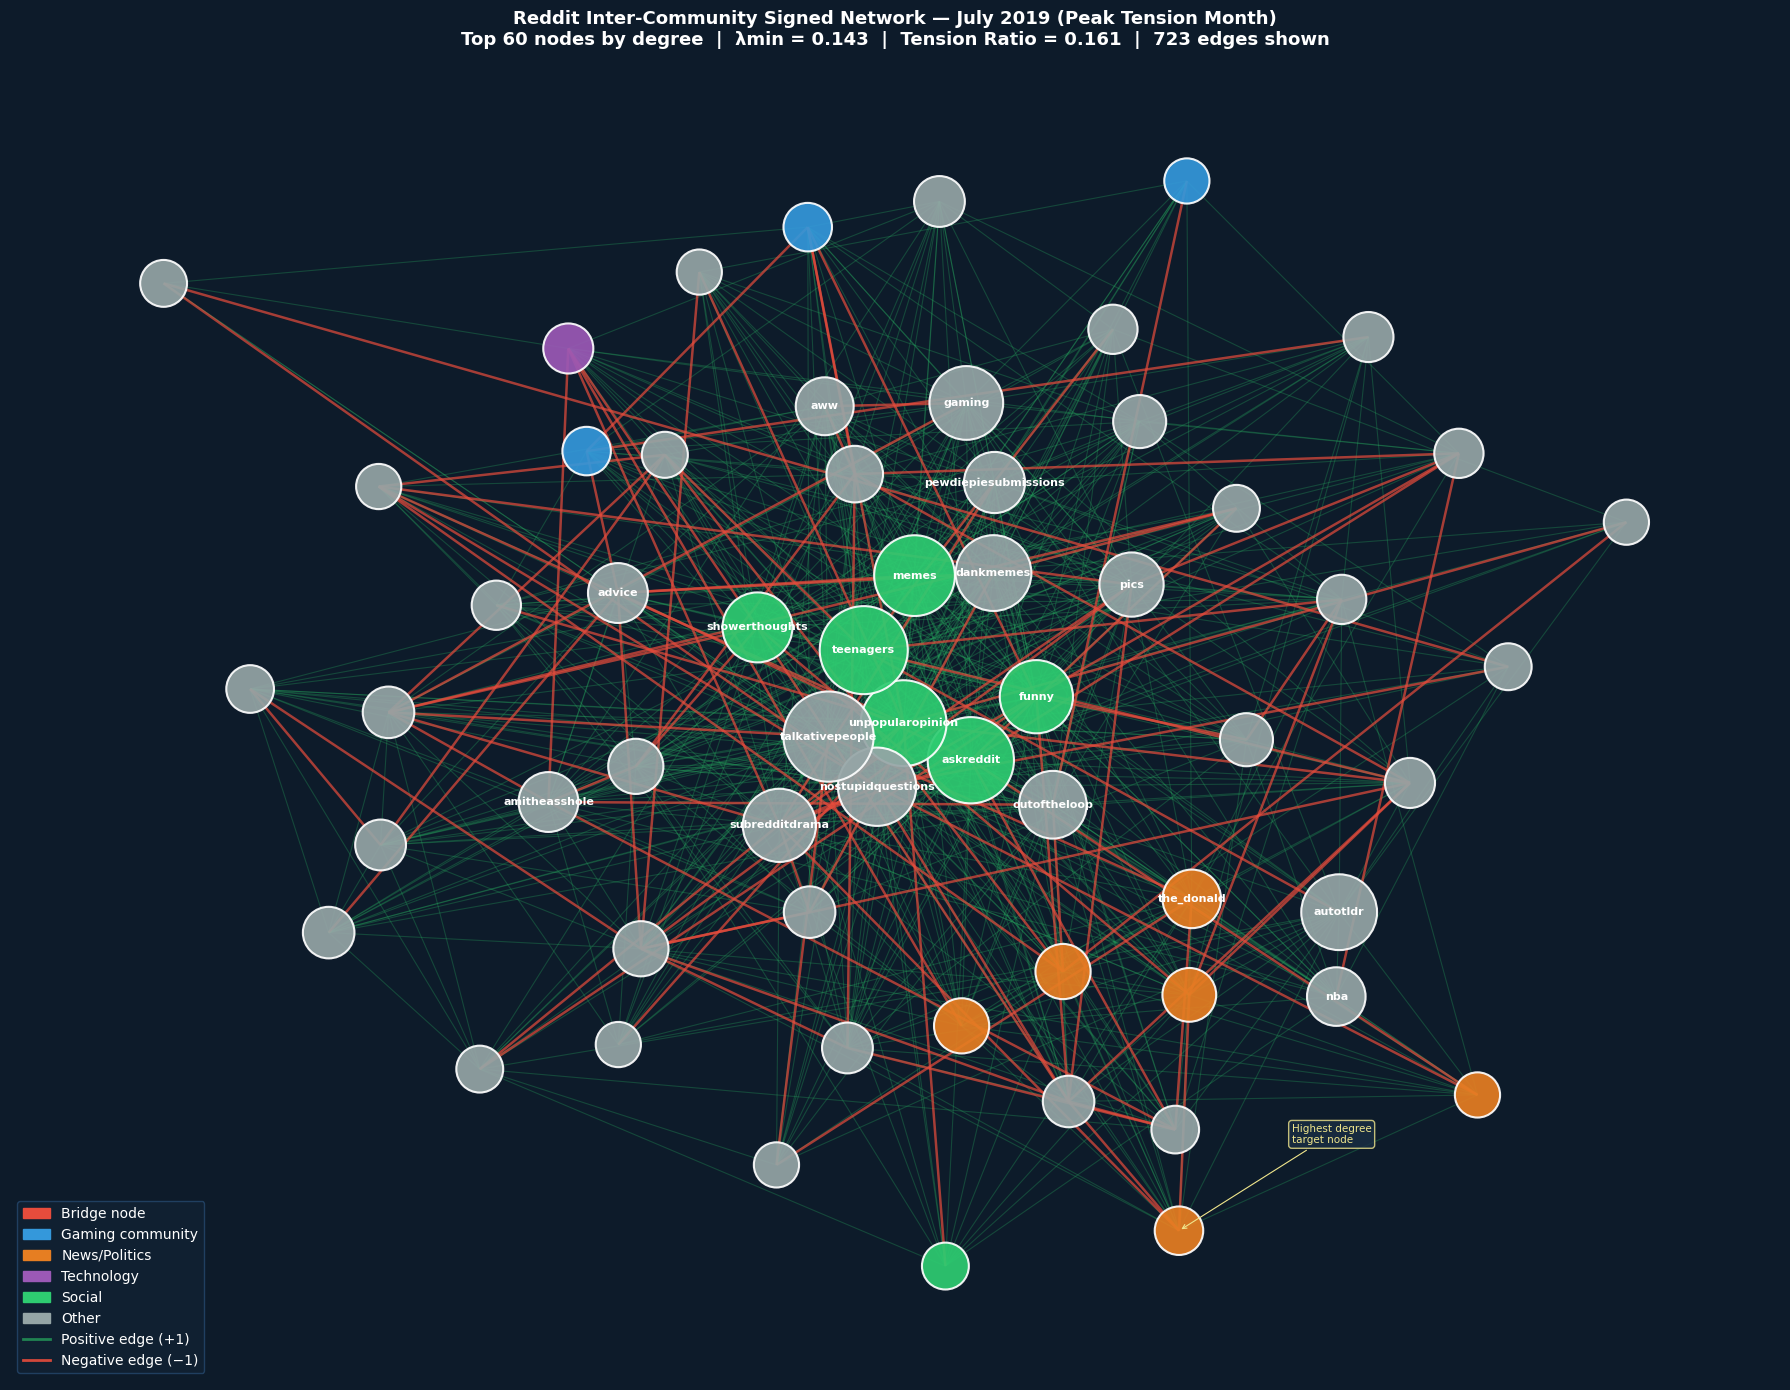

Saved: network_july2019.png


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from matplotlib.lines import Line2D

# ── 1. Load July 2019 snapshot ────────────────────────────────────────────────
month_target = '2019-07'
snap = monthly_edges[monthly_edges['year_month'] == month_target].copy()
print(f"July 2019: {len(snap)} edges, {snap['SOURCE'].nunique()} sources, {snap['TARGET'].nunique()} targets")

# ── 2. Build signed graph ─────────────────────────────────────────────────────
G = nx.Graph()

# Only keep edges with enough weight to reduce visual clutter
edge_threshold = 1  # include all edges (raise to 2+ to reduce clutter)
for _, row in snap.iterrows():
    src, tgt, sign = row['SOURCE'], row['TARGET'], row['sign']
    if G.has_edge(src, tgt):
        # If edge exists, keep dominant sign
        G[src][tgt]['weight'] += abs(sign)
        if abs(sign) > 0:
            G[src][tgt]['sign'] = sign
    else:
        G.add_edge(src, tgt, sign=int(sign), weight=1)

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# ── 3. Filter to top-N nodes for readability ──────────────────────────────────
# Keep top 60 nodes by degree (enough to show structure, not overwhelming)
degree_dict = dict(G.degree())
top_nodes = sorted(degree_dict, key=degree_dict.get, reverse=True)[:60]
G_sub = G.subgraph(top_nodes).copy()

print(f"Subgraph: {G_sub.number_of_nodes()} nodes, {G_sub.number_of_edges()} edges")

# ── 4. Identify node categories ───────────────────────────────────────────────
bridge_nodes = ['market76', 'gunaccessoriesforsale', 'dnd', 
                'leagueoflegends', 'globaloffensivetrade',
                'mechanicadvice', 'destinythegame']

def categorise(node):
    if node in bridge_nodes:
        return 'bridge'
    gaming = ['leagueoflegends','dnd','destinythegame','globaloffensive',
              'globaloffensivetrade','fortnitebr','market76','rocketleague',
              'apexlegends','pokemon','minecraft','gtaonline']
    news   = ['worldnews','news','politics','europe','worldpolitics',
              'ukpolitics','conspiracy','the_donald']
    tech   = ['technology','bitcoin','cryptocurrency','android','apple',
              'pcmasterrace','buildapc','linux']
    social = ['askreddit','teenagers','memes','funny','showerthoughts',
              'todayilearned','tifu','unpopularopinion']
    if node in gaming: return 'gaming'
    if node in news:   return 'news'
    if node in tech:   return 'tech'
    if node in social: return 'social'
    return 'other'

categories = {n: categorise(n) for n in G_sub.nodes()}

# ── 5. Layout ─────────────────────────────────────────────────────────────────
# Spring layout with high-degree nodes pulling toward centre
pos = nx.spring_layout(
    G_sub,
    k=2.5,           # spacing between nodes
    iterations=100,
    seed=42,
    weight='weight'
)

# ── 6. Visual properties ──────────────────────────────────────────────────────
cat_colors = {
    'bridge':  '#e74c3c',   # red — bridge nodes
    'gaming':  '#3498db',   # blue
    'news':    '#e67e22',   # orange
    'tech':    '#9b59b6',   # purple
    'social':  '#2ecc71',   # green
    'other':   '#95a5a6',   # grey
}

node_colors = [cat_colors[categories[n]] for n in G_sub.nodes()]
node_sizes  = [300 + degree_dict[n] * 40 for n in G_sub.nodes()]

# Edge colors: green = positive, red = negative
edge_colors = []
edge_widths = []
edge_alphas = []
for u, v, d in G_sub.edges(data=True):
    sign = d.get('sign', 1)
    if sign >= 0:
        edge_colors.append('#27ae60')   # positive = green
        edge_widths.append(0.8)
        edge_alphas.append(0.4)
    else:
        edge_colors.append('#e74c3c')   # negative = red
        edge_widths.append(1.5)
        edge_alphas.append(0.7)

# ── 7. Draw ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 14))
fig.patch.set_facecolor('#0d1b2a')
ax.set_facecolor('#0d1b2a')

# Draw edges (positive first, then negative on top)
pos_edges = [(u,v) for u,v,d in G_sub.edges(data=True) if d.get('sign',1) >= 0]
neg_edges = [(u,v) for u,v,d in G_sub.edges(data=True) if d.get('sign',1) < 0]

nx.draw_networkx_edges(G_sub, pos, edgelist=pos_edges,
                       edge_color='#27ae60', width=0.8, alpha=0.3, ax=ax)
nx.draw_networkx_edges(G_sub, pos, edgelist=neg_edges,
                       edge_color='#e74c3c', width=1.8, alpha=0.7, ax=ax)

# Draw nodes
nx.draw_networkx_nodes(G_sub, pos,
                       node_color=node_colors,
                       node_size=node_sizes,
                       alpha=0.92, ax=ax,
                       linewidths=1.5,
                       edgecolors='white')

# Labels for top-20 nodes only (avoid overlap)
top20 = sorted(degree_dict, key=degree_dict.get, reverse=True)[:20]
top20_in_sub = [n for n in top20 if n in G_sub.nodes()]
labels = {n: n for n in top20_in_sub}

nx.draw_networkx_labels(G_sub, pos, labels=labels,
                        font_size=8,
                        font_color='white',
                        font_weight='bold',
                        ax=ax)

# ── 8. Legend ─────────────────────────────────────────────────────────────────
legend_elements = [
    # Node categories
    mpatches.Patch(color='#e74c3c', label='Bridge node'),
    mpatches.Patch(color='#3498db', label='Gaming community'),
    mpatches.Patch(color='#e67e22', label='News/Politics'),
    mpatches.Patch(color='#9b59b6', label='Technology'),
    mpatches.Patch(color='#2ecc71', label='Social'),
    mpatches.Patch(color='#95a5a6', label='Other'),
    # Edge types
    Line2D([0],[0], color='#27ae60', linewidth=2, alpha=0.7, label='Positive edge (+1)'),
    Line2D([0],[0], color='#e74c3c', linewidth=2, alpha=0.9, label='Negative edge (−1)'),
]

ax.legend(handles=legend_elements,
          loc='lower left',
          fontsize=10,
          framealpha=0.3,
          facecolor='#1a2e44',
          edgecolor='#4a90d9',
          labelcolor='white')

# ── 9. Annotations for key nodes ──────────────────────────────────────────────
key_annotations = {
    'market76': 'Top bridge\n(48 appearances)',
    'worldnews': 'Highest degree\ntarget node',
}
for node, note in key_annotations.items():
    if node in pos:
        x, y = pos[node]
        ax.annotate(note,
                    xy=(x, y),
                    xytext=(x + 0.15, y + 0.15),
                    fontsize=7.5,
                    color='#f0e68c',
                    arrowprops=dict(arrowstyle='->', color='#f0e68c', lw=0.8),
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='#1a2e44', 
                              edgecolor='#f0e68c', alpha=0.8))

# ── 10. Title and stats ───────────────────────────────────────────────────────
ax.set_title(
    'Reddit Inter-Community Signed Network — July 2019 (Peak Tension Month)\n'
    f'Top 60 nodes by degree  |  \u03bbmin = 0.143  |  Tension Ratio = 0.161  |  '
    f'{G_sub.number_of_edges()} edges shown',
    fontsize=13, fontweight='bold', color='white', pad=16
)

ax.axis('off')
plt.tight_layout()
plt.savefig('network_july2019.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1b2a')
plt.show()
print("Saved: network_july2019.png")

In [21]:
# The annotation "Highest degree target node" is floating without an arrow target
# This is because worldnews wasn't in the top 60 subgraph
# Check:
print('worldnews in subgraph:', 'worldnews' in G_sub.nodes())
print('market76 in subgraph:', 'market76' in G_sub.nodes())

# If market76 is missing, it means July 2019 wasn't its peak bridge month
# Check its degree in July 2019
july_degrees = dict(G_sub.degree())
print("\nAll node degrees in subgraph:")
for n, d in sorted(july_degrees.items(), key=lambda x: x[1], reverse=True)[:15]:
    print(f"  {n}: degree {d}")

worldnews in subgraph: True
market76 in subgraph: False

All node degrees in subgraph:
  unpopularopinion: degree 54
  teenagers: degree 53
  askreddit: degree 52
  talkativepeople: degree 50
  nostupidquestions: degree 47
  funny: degree 43
  memes: degree 43
  dankmemes: degree 41
  showerthoughts: degree 37
  outoftheloop: degree 36
  subredditdrama: degree 34
  pewdiepiesubmissions: degree 32
  pics: degree 32
  gaming: degree 31
  the_donald: degree 27


Bridge nodes in full graph (July 2019):
  market76: degree 3
  gunaccessoriesforsale: degree 2
  dnd: degree 10
  leagueoflegends: degree 9
  globaloffensivetrade: degree 1
  mechanicadvice: degree 2
  destinythegame: degree 13

New subgraph: 57 nodes, 614 edges
Bridge nodes included: ['market76', 'gunaccessoriesforsale', 'dnd', 'leagueoflegends', 'globaloffensivetrade', 'mechanicadvice', 'destinythegame']


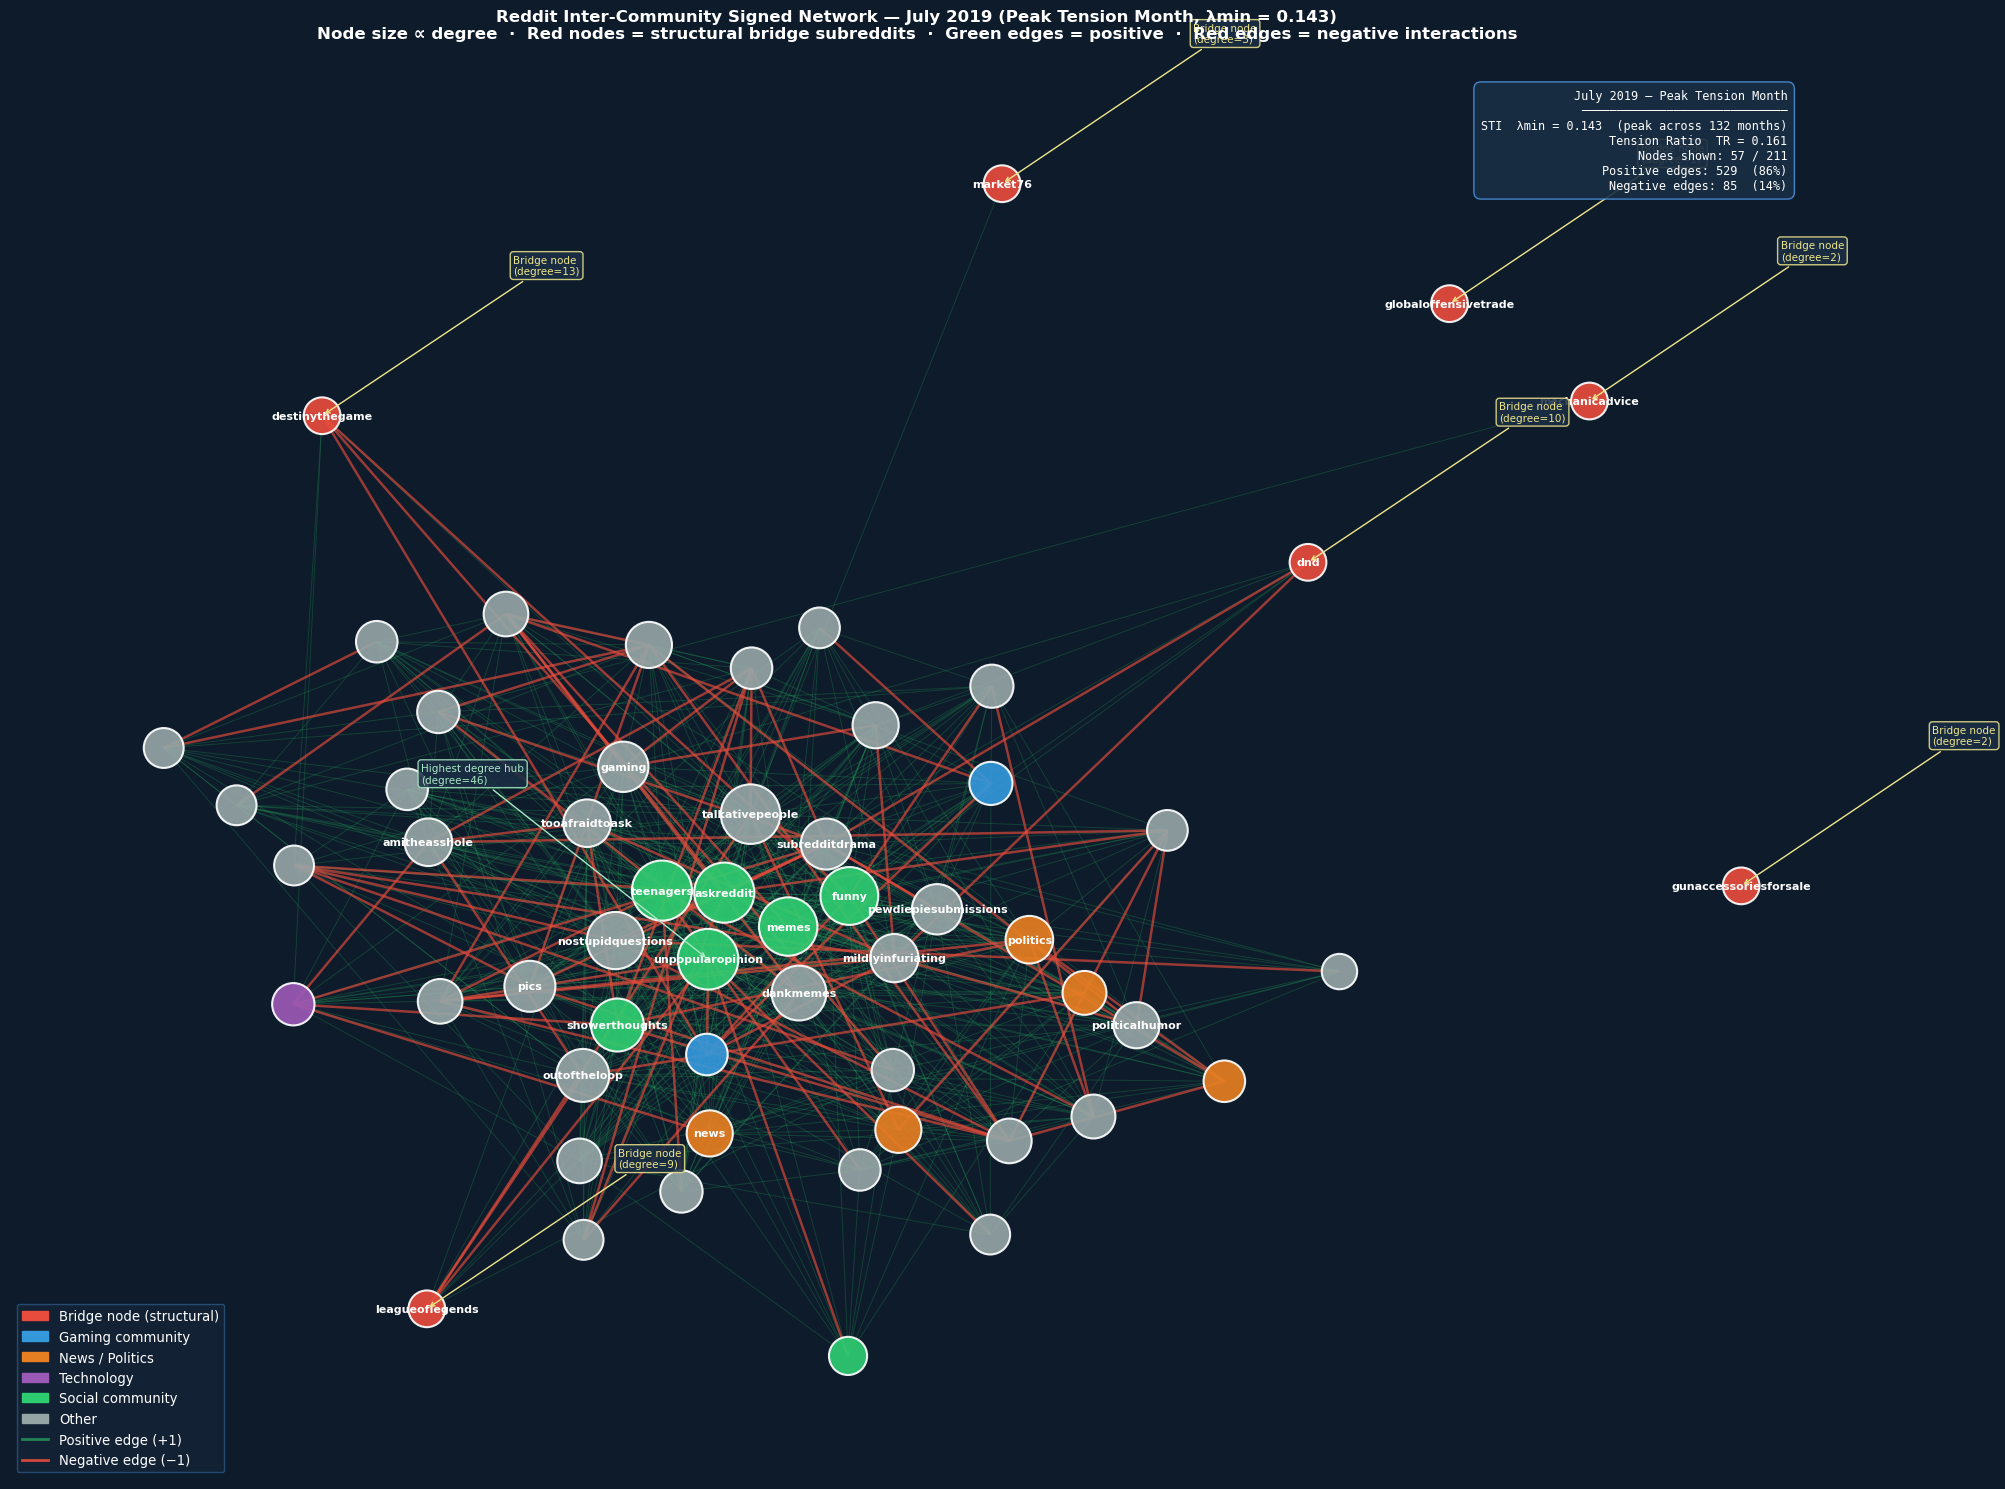

Saved: network_july2019_v2.png


In [22]:
# ── Corrected version ─────────────────────────────────────────────────────────

# Fix 1: Check where bridge nodes actually are
print("Bridge nodes in full graph (July 2019):")
for node in bridge_nodes:
    if node in G.nodes():
        deg = G.degree(node)
        print(f"  {node}: degree {deg}")
    else:
        print(f"  {node}: NOT in graph")

# Fix 2: Include bridge nodes explicitly even if low degree
# Take top 50 by degree + all bridge nodes found in graph
top50 = sorted(degree_dict, key=degree_dict.get, reverse=True)[:50]
bridge_in_graph = [n for n in bridge_nodes if n in G.nodes()]
forced_nodes = list(set(top50 + bridge_in_graph))
G_sub2 = G.subgraph(forced_nodes).copy()

print(f"\nNew subgraph: {G_sub2.number_of_nodes()} nodes, {G_sub2.number_of_edges()} edges")
print(f"Bridge nodes included: {[n for n in bridge_in_graph if n in G_sub2.nodes()]}")

# ── Replot with fixes ─────────────────────────────────────────────────────────
pos2 = nx.spring_layout(G_sub2, k=2.8, iterations=120, seed=42, weight='weight')

degree_dict2 = dict(G_sub2.degree())
categories2  = {n: categorise(n) for n in G_sub2.nodes()}
node_colors2 = [cat_colors[categories2[n]] for n in G_sub2.nodes()]

# Scale sizes — bridge nodes get a size boost even if low degree
node_sizes2 = []
for n in G_sub2.nodes():
    base = 300 + degree_dict2[n] * 35
    if n in bridge_nodes:
        base = max(base, 700)   # minimum size for bridge nodes
    node_sizes2.append(base)

pos_edges2 = [(u,v) for u,v,d in G_sub2.edges(data=True) if d.get('sign',1) >= 0]
neg_edges2 = [(u,v) for u,v,d in G_sub2.edges(data=True) if d.get('sign',1) < 0]

fig, ax = plt.subplots(figsize=(20, 15))
fig.patch.set_facecolor('#0d1b2a')
ax.set_facecolor('#0d1b2a')

# Draw edges
nx.draw_networkx_edges(G_sub2, pos2, edgelist=pos_edges2,
                       edge_color='#27ae60', width=0.7, alpha=0.25, ax=ax)
nx.draw_networkx_edges(G_sub2, pos2, edgelist=neg_edges2,
                       edge_color='#e74c3c', width=1.8, alpha=0.65, ax=ax)

# Draw nodes
nx.draw_networkx_nodes(G_sub2, pos2,
                       node_color=node_colors2,
                       node_size=node_sizes2,
                       alpha=0.92, ax=ax,
                       linewidths=1.5,
                       edgecolors='white')

# Labels: top 20 by degree + all bridge nodes
top20_v2 = sorted(degree_dict2, key=degree_dict2.get, reverse=True)[:20]
label_nodes = list(set(top20_v2 + bridge_in_graph))
labels2 = {n: n for n in label_nodes if n in G_sub2.nodes()}

nx.draw_networkx_labels(G_sub2, pos2, labels=labels2,
                        font_size=8, font_color='white',
                        font_weight='bold', ax=ax)

# ── Annotate bridge nodes specifically ───────────────────────────────────────
for node in bridge_in_graph:
    if node in pos2:
        x, y = pos2[node]
        deg  = G.degree(node)
        ax.annotate(
            f'Bridge node\n(degree={deg})',
            xy=(x, y), xytext=(x + 0.2, y + 0.2),
            fontsize=7.5, color='#f0e68c',
            arrowprops=dict(arrowstyle='->', color='#f0e68c', lw=1.0),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#1a2e44',
                      edgecolor='#f0e68c', alpha=0.85)
        )

# ── Annotate top social hub ───────────────────────────────────────────────────
hub = 'unpopularopinion'  # highest degree in July 2019
if hub in pos2:
    x, y = pos2[hub]
    ax.annotate(
        f'Highest degree hub\n(degree={degree_dict2[hub]})',
        xy=(x, y), xytext=(x - 0.3, y + 0.25),
        fontsize=7.5, color='#a8e8c4',
        arrowprops=dict(arrowstyle='->', color='#a8e8c4', lw=1.0),
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#1a2e44',
                  edgecolor='#a8e8c4', alpha=0.85)
    )

# ── Stats box (top right) ─────────────────────────────────────────────────────
stats_text = (
    "July 2019 — Peak Tension Month\n"
    "─────────────────────────────\n"
    f"STI  λmin = 0.143  (peak across 132 months)\n"
    f"Tension Ratio  TR = 0.161\n"
    f"Nodes shown: {G_sub2.number_of_nodes()} / {G.number_of_nodes()}\n"
    f"Positive edges: {len(pos_edges2)}  ({len(pos_edges2)/(len(pos_edges2)+len(neg_edges2))*100:.0f}%)\n"
    f"Negative edges: {len(neg_edges2)}  ({len(neg_edges2)/(len(pos_edges2)+len(neg_edges2))*100:.0f}%)"
)
ax.text(0.98, 0.98, stats_text,
        transform=ax.transAxes,
        fontsize=8.5, color='white',
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.6', facecolor='#1a2e44',
                  edgecolor='#4a90d9', alpha=0.9),
        fontfamily='monospace')

# ── Legend ────────────────────────────────────────────────────────────────────
legend_elements = [
    mpatches.Patch(color='#e74c3c', label='Bridge node (structural)'),
    mpatches.Patch(color='#3498db', label='Gaming community'),
    mpatches.Patch(color='#e67e22', label='News / Politics'),
    mpatches.Patch(color='#9b59b6', label='Technology'),
    mpatches.Patch(color='#2ecc71', label='Social community'),
    mpatches.Patch(color='#95a5a6', label='Other'),
    Line2D([0],[0], color='#27ae60', linewidth=2, alpha=0.7, label='Positive edge (+1)'),
    Line2D([0],[0], color='#e74c3c', linewidth=2, alpha=0.9, label='Negative edge (\u22121)'),
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=9.5,
          framealpha=0.4, facecolor='#1a2e44',
          edgecolor='#4a90d9', labelcolor='white')

# ── Title ─────────────────────────────────────────────────────────────────────
ax.set_title(
    'Reddit Inter-Community Signed Network \u2014 July 2019 (Peak Tension Month, \u03bbmin = 0.143)\n'
    'Node size \u221d degree  \u00b7  Red nodes = structural bridge subreddits  \u00b7  '
    'Green edges = positive  \u00b7  Red edges = negative interactions',
    fontsize=12, fontweight='bold', color='white', pad=16
)

ax.axis('off')
plt.tight_layout()
plt.savefig('network_july2019_v2.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1b2a')
plt.show()
print("Saved: network_july2019_v2.png")